# 02 — Zone Detection Analysis

**Project:** ZoneTrend — AI-assisted swing trading via support/resistance zone detection  
**Notebook purpose:** Visually and statistically validate the zones detected by `zone_detector.py`.  
Every algorithmic step must be visually verified before it can be trusted in downstream work.

---

### Research questions answered here

| # | Question | Why it matters |
|---|----------|----------------|
| 1 | Do the detected zones visually correspond to real price structure? | Algorithm correctness check |
| 2 | What is the distribution of zone types, strengths, and widths? | Understand what the detector found |
| 3 | How do demand vs. supply zones differ structurally? | Asymmetric market behaviour |
| 4 | Where are the active / tested zones relative to the current price? | Immediately tradeable insights |
| 5 | How sensitive are zone counts to the key parameters? | Calibration and robustness check |
| 6 | What does the zone lifecycle look like (active → tested → consumed / invalid)? | Informs labelling strategy |

---

**Pre-requisites** — run from the `ZoneTrend/` root:
```bash
python run_pipeline.py                 # full pipeline (or --skip-fetch if data exists)
python run_pipeline.py --skip-fetch --skip-preprocess   # zones only
```

---
## 0 · Setup

In [26]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yaml
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 130)

# Matplotlib kept for distribution / stats charts
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

# Zone colour constants (used in both Plotly and matplotlib)
DEMAND_FILL   = 'rgba(38,166,154,0.12)'
DEMAND_LINE   = 'rgba(38,166,154,0.75)'
SUPPLY_FILL   = 'rgba(239,83,80,0.12)'
SUPPLY_LINE   = 'rgba(239,83,80,0.75)'
CHART_THEME   = 'plotly_dark'
PAPER_BG      = '#131722'   # TradingView dark background
PLOT_BG       = '#131722'
GRID_COLOR    = '#1e222d'

print(f'Project root : {PROJECT_ROOT}')
import plotly; print(f'Plotly       : {plotly.__version__}')
import pandas as pd2; print(f'Pandas       : {pd2.__version__}')


Project root : /Users/sachinchoudhary/Desktop/RI/ZoneTrend
Plotly       : 6.7.0
Pandas       : 2.3.3


In [27]:
# ── Load configs ──────────────────────────────────────────────
with open(PROJECT_ROOT / 'config' / 'config.yaml') as f:
    CFG = yaml.safe_load(f)
with open(PROJECT_ROOT / 'config' / 'zone_config.yaml') as f:
    ZCFG = yaml.safe_load(f)['zones']

SYMBOL = CFG['data']['symbol']
SAFE   = SYMBOL.replace('.', '_').replace('^', 'IDX_')

PROC_PATH  = PROJECT_ROOT / CFG['data']['processed_dir'] / f'{SAFE}.csv'
ZONES_PATH = PROJECT_ROOT / CFG['data']['zones_dir']     / f'{SAFE}_zones.csv'

print(f'Symbol     : {SYMBOL}')
print(f'Processed  : {PROC_PATH.relative_to(PROJECT_ROOT)}  exists={PROC_PATH.exists()}')
print(f'Zones      : {ZONES_PATH.relative_to(PROJECT_ROOT)}  exists={ZONES_PATH.exists()}')

Symbol     : ^NSEI
Processed  : data/processed/IDX_NSEI.csv  exists=True
Zones      : data/zones/IDX_NSEI_zones.csv  exists=True


---
## 1 · Load Data

In [28]:
# ── Price data ────────────────────────────────────────────────
proc = pd.read_csv(PROC_PATH, index_col='Date', parse_dates=True)
proc.index = pd.to_datetime(proc.index).tz_localize(None)
proc.sort_index(inplace=True)

# ── Zone data ─────────────────────────────────────────────────
zones = pd.read_csv(ZONES_PATH, index_col='zone_id')
for c in ['formation_date', 'base_start_date', 'base_end_date',
          'last_test_date', 'invalidation_date']:
    zones[c] = pd.to_datetime(zones[c])
zones.sort_values('formation_date', inplace=True)

print(f'Price data : {len(proc):,} rows  |  {proc.index.min().date()} → {proc.index.max().date()}')
print(f'Zones      : {len(zones)} zones detected')
print()
print('Zone DataFrame columns:')
print(list(zones.columns))

Price data : 2,828 rows  |  2015-01-02 → 2026-07-01
Zones      : 100 zones detected

Zone DataFrame columns:
['type', 'structure', 'top', 'bottom', 'midpoint', 'proximal', 'distal', 'width', 'width_atr', 'formation_date', 'formation_idx', 'base_start_date', 'base_end_date', 'base_length', 'base_wick_frac', 'avg_atr', 'departure_body_atr', 'departure_close_ratio', 'leg_out_clear_atr', 'leg_out_disp_atr', 'leg_out_candles', 'leg_out_velocity', 'leg_out_vol_exp', 'leg_in_disp_atr', 'leg_in_candles', 'leg_in_velocity', 'disp_base_ratio', 'arrival_cleanliness', 'departure_volume_ratio', 'base_volume_ratio', 'trend_score', 'trend_aligned', 'strength', 'quality_score', 'weekly_trend_align', 'weekly_in_zone', 'weekly_dist_atr', 'weekly_zone_strength', 'weekly_zone_fresh', 'weekly_confluence_score', 'weekly_confirmed', 'freshness_score', 'strength_pit', 'adjusted_strength_posthoc', 'merged_count', 'test_count', 'status', 'last_test_date', 'invalidation_date']


In [29]:
# Full zone table — ranked by the NEW quality_score (0-100).
# `strength` is the DEPRECATED legacy score (kept only for reference; it was
# anti-predictive — see SD_ZONE_DEEP_ANALYSIS.md). Rank/filter on quality_score.
display_cols = [
    'type', 'structure', 'shape', 'top', 'bottom', 'proximal', 'distal', 'width_atr',
    'base_length', 'base_wick_frac', 'leg_out_disp_atr', 'leg_out_candles',
    'leg_in_disp_atr', 'disp_base_ratio', 'is_v_shape', 'weekly_in_zone',
    'quality_score', 'strength', 'status', 'test_count',
]
display_cols = [c for c in display_cols if c in zones.columns]
zones.sort_values('quality_score', ascending=False)[display_cols]

,type,structure,top,bottom,proximal,distal,width_atr,base_length,base_wick_frac,leg_out_disp_atr,leg_out_candles,leg_in_disp_atr,disp_base_ratio,weekly_in_zone,quality_score,strength,status,test_count
zone_id,,,,,,,,,,,,,,,,,,
Z0021,supply,RBD,7252.3999,7127.8501,7170.5498,7252.3999,0.9608,3,0.6350,1.0719,3,0.3942,1.1156,False,93.0700,0.7129,broken,1
Z0085,demand,RBR,18419.7500,18202.4004,18362.9004,18202.4004,1.4160,3,0.7879,0.8763,3,0.1753,0.6188,False,92.6200,0.6841,active,0
Z0053,supply,RBD,10604.9004,10410.1504,10512.5000,10604.9004,1.0519,2,0.7635,1.6541,4,0.7597,1.5725,False,91.9700,0.7670,broken,1
Z0050,demand,RBR,11620.7002,11532.0000,11620.7002,11532.0000,1.0864,3,0.7205,0.5702,2,1.8936,0.5248,False,90.2000,0.7474,broken,1
Z0062,demand,RBR,11481.0498,11290.0498,11464.9502,11290.0498,1.1151,3,0.7703,0.4408,2,0.8880,0.3953,False,90.0000,0.6373,broken,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Z0071,supply,RBD,11618.0996,11446.0996,11504.9502,11618.0996,1.2102,3,0.4862,3.1310,4,0.5207,2.5872,False,21.4200,0.7413,broken,1
Z0098,supply,DBD,25907.5996,25739.1992,25788.4492,25907.5996,0.7833,1,0.9498,2.1132,3,0.9049,2.6980,True,20.6200,0.7294,broken,1
Z0022,demand,DBR,7569.3501,7526.7002,7555.2002,7526.7002,0.4327,1,0.6987,2.4685,4,1.9262,5.7045,False,18.2500,0.7897,tested,1


---
## 2 · Visual Inspection — Zones on Full Price History

This is the most important check.  
Every detected zone must be plotted on the chart and manually verified to look structurally correct.  
An algorithm that passes unit tests but draws wrong zones is not a valid algorithm.

**Reading the chart:**
- Green shaded rectangles = Demand zones (DBR — support)
- Red shaded rectangles = Supply zones (RBD — resistance)
- Rectangle spans the zone horizontally from `base_start_date` to end of chart (zone stays visible)
- Dashed border = invalidated zone  |  Solid border = active or tested zone

In [30]:
def plot_zones_on_candles(
    proc: pd.DataFrame,
    zones: pd.DataFrame,
    title: str = '',
    n_candles: int | None = None,
    show_emas: bool = True,
) -> go.Figure:
    """
    Broker-style interactive candlestick chart with RBD/DBR zone overlays.

    Features
    --------
    - OHLCV candlesticks (green/red, TradingView palette)
    - Volume bars coloured by candle direction
    - EMA 20 / 50 / 200 overlay
    - Supply/demand zone bands with hover tooltip (zone id, type, strength,
      status, test count, formation date)
    - Solid borders = active/tested zones  |  Dotted = invalid/consumed
    - Range selector buttons: 1M · 3M · 6M · 1Y · 2Y · ALL
    - Crosshair cursor, unified hover mode
    - Dark theme matching Angel One / TradingView
    """
    df = proc.tail(n_candles).copy() if n_candles else proc.copy()
    date_min = df.index.min()
    date_max = df.index.max()

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.78, 0.22],
        vertical_spacing=0.02,
    )

    # ── 1. Candlesticks ───────────────────────────────────────────────────
    fig.add_trace(go.Candlestick(
        x=df.index,
        open=df['Open'], high=df['High'], low=df['Low'], close=df['Close'],
        name='Price',
        increasing=dict(line=dict(color='#26a69a', width=1),
                        fillcolor='#26a69a'),
        decreasing=dict(line=dict(color='#ef5350', width=1),
                        fillcolor='#ef5350'),
        whiskerwidth=0.5,
        hoverinfo='x+y',
    ), row=1, col=1)

    # ── 2. Volume bars ────────────────────────────────────────────────────
    vol_colors = ['#26a69a' if c >= o else '#ef5350'
                  for c, o in zip(df['Close'], df['Open'])]
    fig.add_trace(go.Bar(
        x=df.index,
        y=df['Volume'].replace(0, None),
        marker_color=vol_colors,
        name='Volume',
        opacity=0.55,
        showlegend=False,
        hovertemplate='Vol: %{y:,.0f}<extra></extra>',
    ), row=2, col=1)

    # ── 3. EMA lines ──────────────────────────────────────────────────────
    if show_emas:
        for period, color, width, dash in [
            (20,  '#ff9800', 1.0, 'solid'),
            (50,  '#2196F3', 1.2, 'solid'),
            (200, '#ce93d8', 1.6, 'solid'),
        ]:
            col_name = f'EMA{period}'
            if col_name in df.columns:
                fig.add_trace(go.Scatter(
                    x=df.index, y=df[col_name],
                    name=f'EMA {period}',
                    line=dict(color=color, width=width, dash=dash),
                    hovertemplate=f'EMA{period}: %{{y:.2f}}<extra></extra>',
                ), row=1, col=1)

    # ── 4. Zone bands ─────────────────────────────────────────────────────
    for zone_id, z in zones.iterrows():
        fdate    = pd.Timestamp(z['formation_date'])
        is_demand = z['type'] == 'demand'
        is_live   = z['status'] in ('active', 'tested')

        # Skip zones entirely outside the chart window
        inv = z.get('invalidation_date')
        if pd.notna(inv) and pd.Timestamp(inv) < date_min:
            continue
        if fdate > date_max:
            continue

        fill  = DEMAND_FILL if is_demand else SUPPLY_FILL
        line  = DEMAND_LINE if is_demand else SUPPLY_LINE
        dash  = 'solid'     if is_live   else 'dot'

        x0 = max(fdate, date_min)
        x1 = date_max

        # Filled rectangle (shape — rendered behind candles)
        fig.add_shape(
            type='rect',
            xref='x', yref='y',
            x0=x0, x1=x1,
            y0=float(z['bottom']), y1=float(z['top']),
            fillcolor=fill,
            line=dict(color=line, width=1, dash=dash),
            layer='below',
        )

        # Invisible filled scatter → gives hover tooltip over the zone area
        hover_txt = (
            f"<b>{zone_id}</b>  {'🟢 Demand' if is_demand else '🔴 Supply'}<br>"
            f"Top: <b>{z['top']:.2f}</b>  Bottom: <b>{z['bottom']:.2f}</b><br>"
            f"Width: {z['width_atr']:.2f}× ATR<br>"
            f"Quality: <b>{z['quality_score']:.0f}</b>/100<br>"
            f"Status: <b>{z['status']}</b>  |  Tests: {int(z['test_count'])}<br>"
            f"Formed: {fdate.strftime('%d %b %Y')}"
            "<extra></extra>"
        )
        fig.add_trace(go.Scatter(
            x=[x0, x1, x1, x0, x0],
            y=[z['bottom'], z['bottom'], z['top'], z['top'], z['bottom']],
            fill='toself',
            fillcolor='rgba(0,0,0,0)',
            line=dict(color='rgba(0,0,0,0)'),
            name=zone_id,
            showlegend=False,
            hovertemplate=hover_txt,
        ), row=1, col=1)

        # Zone label at left edge
        fig.add_annotation(
            xref='x', yref='y',
            x=x0, y=float(z['midpoint']),
            text=f" {zone_id}  Q{z['quality_score']:.0f}",
            showarrow=False, xanchor='left',
            font=dict(size=8, color=line),
        )

    # ── 5. Layout ─────────────────────────────────────────────────────────
    fig.update_layout(
        title=dict(
            text=title or f'<b>{SYMBOL}</b>  —  RBD / DBR Supply & Demand Zones',
            font=dict(size=14, color='#d1d4dc'),
            x=0.0, xanchor='left',
            y=0.98, yanchor='top',
        ),
        template=CHART_THEME,
        paper_bgcolor=PAPER_BG,
        plot_bgcolor=PLOT_BG,
        height=710,
        margin=dict(l=65, r=25, t=50, b=70),
        legend=dict(
            orientation='h', yanchor='top', y=-0.06, xanchor='right', x=1.0,
            font=dict(size=10, color='#d1d4dc'),
            bgcolor='rgba(0,0,0,0)',
        ),
        xaxis_rangeslider_visible=False,
        hovermode='x unified',
        hoverlabel=dict(bgcolor='#1e222d', font_size=11),
    )

    # Range selector + grid styling (price panel)
    # Compute holiday breaks: weekdays present in calendar but absent from data
    all_days     = pd.date_range(df.index.min(), df.index.max(), freq='D')
    trading_set  = set(df.index.normalize())
    holidays     = [d.strftime('%Y-%m-%d') for d in all_days
                    if d not in trading_set and d.weekday() < 5]
    range_breaks = [dict(bounds=['sat', 'mon']), dict(values=holidays)]

    fig.update_xaxes(
        rangeselector=dict(
            buttons=[
                dict(count=1,  label='1M',  step='month', stepmode='backward'),
                dict(count=3,  label='3M',  step='month', stepmode='backward'),
                dict(count=6,  label='6M',  step='month', stepmode='backward'),
                dict(count=1,  label='1Y',  step='year',  stepmode='backward'),
                dict(count=2,  label='2Y',  step='year',  stepmode='backward'),
                dict(step='all', label='ALL'),
            ],
            bgcolor='#1e222d', activecolor='#2196F3',
            font=dict(color='#d1d4dc', size=10),
            x=0.0, xanchor='left', y=-0.12, yanchor='top',
        ),
        showgrid=True, gridcolor=GRID_COLOR, gridwidth=1,
        zeroline=False,
        rangebreaks=range_breaks,
        row=1, col=1,
    )
    fig.update_xaxes(
        showgrid=True, gridcolor=GRID_COLOR,
        rangebreaks=range_breaks,
        row=2, col=1,
    )
    fig.update_yaxes(
        title_text='Price (INR)', gridcolor=GRID_COLOR,
        tickformat=',.0f', side='right',
        row=1, col=1,
    )
    fig.update_yaxes(
        title_text='Volume', gridcolor=GRID_COLOR,
        tickformat='.2s', side='right',
        row=2, col=1,
    )

    return fig


In [31]:
# ── Full price history ────────────────────────────────────────────────────
fig_full = plot_zones_on_candles(
    proc, zones,
    title=f'<b>{SYMBOL}</b>  —  All RBD/DBR Zones  |  Full history',
)
fig_full.show()


---
## 3 · Individual Zone Deep Dives

Each detected zone is plotted individually as a candlestick chart showing:
- The arrival leg (price moving into the base)
- The base candles (highlighted)
- The departure candle (the strong move away)
- A window of subsequent price action to see how the zone was tested

This is the definitive correctness check for the pattern detection logic.

In [32]:
def plot_zone_detail(
    proc: pd.DataFrame,
    zone:  pd.Series,
    zid:   str,
    context: int = 25,
) -> go.Figure:
    """
    Broker-style Plotly candlestick zoom-in on a single RBD/DBR zone.

    Shows: arrival leg → base → departure candle → subsequent reaction window.
    Vertical lines mark the base start and departure (zone formation) date.
    The zone band is shaded. Volume subplot included.

    Note: Timestamps are converted to ISO strings for Plotly 6.x / pandas 2.x
    compatibility (Plotly's add_vline internally calls sum() on x which
    breaks with pandas Timestamps).
    """
    base_start = pd.Timestamp(zone['base_start_date'])
    dep_date   = pd.Timestamp(zone['formation_date'])

    try:
        base_pos = proc.index.get_loc(base_start)
    except KeyError:
        base_pos = int(proc.index.searchsorted(base_start))
    try:
        dep_pos  = proc.index.get_loc(dep_date)
    except KeyError:
        dep_pos  = int(proc.index.searchsorted(dep_date))

    lo     = max(0, base_pos - context)
    hi     = min(len(proc), dep_pos + context + 1)
    window = proc.iloc[lo:hi].copy()

    is_demand = zone['type'] == 'demand'
    fill  = DEMAND_FILL if is_demand else SUPPLY_FILL
    line  = DEMAND_LINE if is_demand else SUPPLY_LINE
    ztype = 'Demand (DBR — Drop → Base → Rally)' if is_demand \
            else 'Supply (RBD — Rally → Base → Drop)'

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.78, 0.22],
        vertical_spacing=0.02,
    )

    # Candlesticks
    fig.add_trace(go.Candlestick(
        x=window.index,
        open=window['Open'], high=window['High'],
        low=window['Low'],   close=window['Close'],
        name='Price',
        increasing=dict(line=dict(color='#26a69a', width=1), fillcolor='#26a69a'),
        decreasing=dict(line=dict(color='#ef5350', width=1), fillcolor='#ef5350'),
        whiskerwidth=0.5,
    ), row=1, col=1)

    # Volume bars
    vol_colors = ['#26a69a' if c >= o else '#ef5350'
                  for c, o in zip(window['Close'], window['Open'])]
    fig.add_trace(go.Bar(
        x=window.index, y=window['Volume'].replace(0, None),
        marker_color=vol_colors, showlegend=False, opacity=0.55,
        hovertemplate='Vol: %{y:,.0f}<extra></extra>',
    ), row=2, col=1)

    # ATR line on volume panel
    if 'ATR' in window.columns:
        fig.add_trace(go.Scatter(
            x=window.index, y=window['ATR'],
            name='ATR', line=dict(color='#ff9800', width=1.2, dash='dot'),
            hovertemplate='ATR: %{y:.2f}<extra></extra>',
        ), row=2, col=1)

    # Zone band (add_shape uses DatetimeIndex values — works fine)
    fig.add_shape(
        type='rect', xref='x', yref='y',
        x0=window.index[0], x1=window.index[-1],
        y0=float(zone['bottom']), y1=float(zone['top']),
        fillcolor=fill, line=dict(color=line, width=1.5),
        layer='below',
    )

    # Boundary lines
    for y_val, label in [(zone['top'], 'Zone Top'), (zone['bottom'], 'Zone Bot')]:
        fig.add_hline(
            y=float(y_val), line_color=line, line_width=1.2, line_dash='dash',
            annotation_text=f' {label} {y_val:.2f}',
            annotation_font_color=line, annotation_font_size=9,
            row=1, col=1,
        )

    # ── Vertical markers via add_shape + add_annotation ──────────────────────
    # add_vline is broken in Plotly 6 / pandas 2 because its internal mean()
    # helper does sum([x_value]) starting from int(0), which fails for both
    # Timestamps and strings.  add_shape bypasses that code path entirely.

    if base_start in window.index:
        fig.add_shape(
            type='line', xref='x', yref='paper',
            x0=base_start, x1=base_start, y0=0, y1=1,
            line=dict(color='#aaaaaa', width=1.2, dash='dot'),
        )
        fig.add_annotation(
            xref='x', yref='paper',
            x=base_start, y=0.98,
            text=' Base start', showarrow=False, xanchor='left',
            font=dict(size=9, color='#aaaaaa'),
        )

    if dep_date in window.index:
        dep_color = '#26a69a' if is_demand else '#ef5350'
        fig.add_shape(
            type='line', xref='x', yref='paper',
            x0=dep_date, x1=dep_date, y0=0, y1=1,
            line=dict(color=dep_color, width=1.8, dash='solid'),
        )
        fig.add_annotation(
            xref='x', yref='paper',
            x=dep_date, y=0.92,
            text=' Zone formed', showarrow=False, xanchor='left',
            font=dict(size=9, color=dep_color),
        )

    # Holiday rangebreaks for this window
    all_days_w    = pd.date_range(window.index.min(), window.index.max(), freq='D')
    trading_set_w = set(window.index.normalize())
    holidays_w    = [d.strftime('%Y-%m-%d') for d in all_days_w
                     if d not in trading_set_w and d.weekday() < 5]
    range_breaks_w = [dict(bounds=['sat', 'mon']), dict(values=holidays_w)]

    fig.update_layout(
        title=dict(
            text=(
                f'<b>{zid}</b>  {ztype}<br>'
                f'<sub>Zone: {zone["bottom"]:.2f} – {zone["top"]:.2f}  '
                f'| Width: {zone["width_atr"]:.2f}× ATR  '
                f'| Strength: {zone["strength"]:.3f}  '
                f'| Status: <b>{zone["status"]}</b>  '
                f'| Tests: {int(zone["test_count"])}  '
                f'| Base: {int(zone["base_length"])} candle(s)</sub>'
            ),
            font=dict(size=12, color='#d1d4dc'),
            x=0.0, xanchor='left',
        ),
        template=CHART_THEME,
        paper_bgcolor=PAPER_BG,
        plot_bgcolor=PLOT_BG,
        height=540,
        margin=dict(l=65, r=25, t=75, b=50),
        xaxis_rangeslider_visible=False,
        hovermode='x unified',
        hoverlabel=dict(bgcolor='#1e222d', font_size=10),
        legend=dict(
            font=dict(size=9), bgcolor='rgba(0,0,0,0)',
            orientation='h', yanchor='top', y=-0.08, xanchor='right', x=1.0,
        ),
        showlegend=True,
    )
    fig.update_xaxes(
        gridcolor=GRID_COLOR, zeroline=False,
        rangebreaks=range_breaks_w,
    )
    fig.update_yaxes(gridcolor=GRID_COLOR, tickformat=',.0f',
                     side='right', row=1, col=1)
    fig.update_yaxes(gridcolor=GRID_COLOR, side='right', row=2, col=1)

    return fig


# ── Plot every detected zone ──────────────────────────────────────────────
print(f'Plotting all {len(zones)} zones individually...\n')
for zid, zone in zones.iterrows():
    fig = plot_zone_detail(proc, zone, zid, context=25)
    fig.show()


Plotting all 100 zones individually...



---
## 4 · Zone Distribution Analysis

Statistical summary of what was detected.  
This section builds intuition for what the detector finds on this instrument and informs parameter tuning.

In [33]:
# ── 4a. High-level counts ─────────────────────────────────────
n_total   = len(zones)
n_demand  = (zones['type'] == 'demand').sum()
n_supply  = (zones['type'] == 'supply').sum()
n_years   = (proc.index.max() - proc.index.min()).days / 365.25

print('=' * 50)
print(f'  Total zones     : {n_total}')
print(f'  Demand (DBR)    : {n_demand}  ({n_demand/n_total*100:.0f}%)')
print(f'  Supply (RBD)    : {n_supply}  ({n_supply/n_total*100:.0f}%)')
print(f'  Years of data   : {n_years:.1f}')
print(f'  Zones per year  : {n_total/n_years:.1f}')
print('=' * 50)
print()
print('Status breakdown:')
print(zones['status'].value_counts().to_string())
print()
print('Base length distribution:')
print(zones['base_length'].value_counts().sort_index().to_string())

  Total zones     : 100
  Demand (DBR)    : 47  (47%)
  Supply (RBD)    : 53  (53%)
  Years of data   : 11.5
  Zones per year  : 8.7

Status breakdown:
status
broken    93
tested     5
active     2

Base length distribution:
base_length
1    38
2    18
3    44


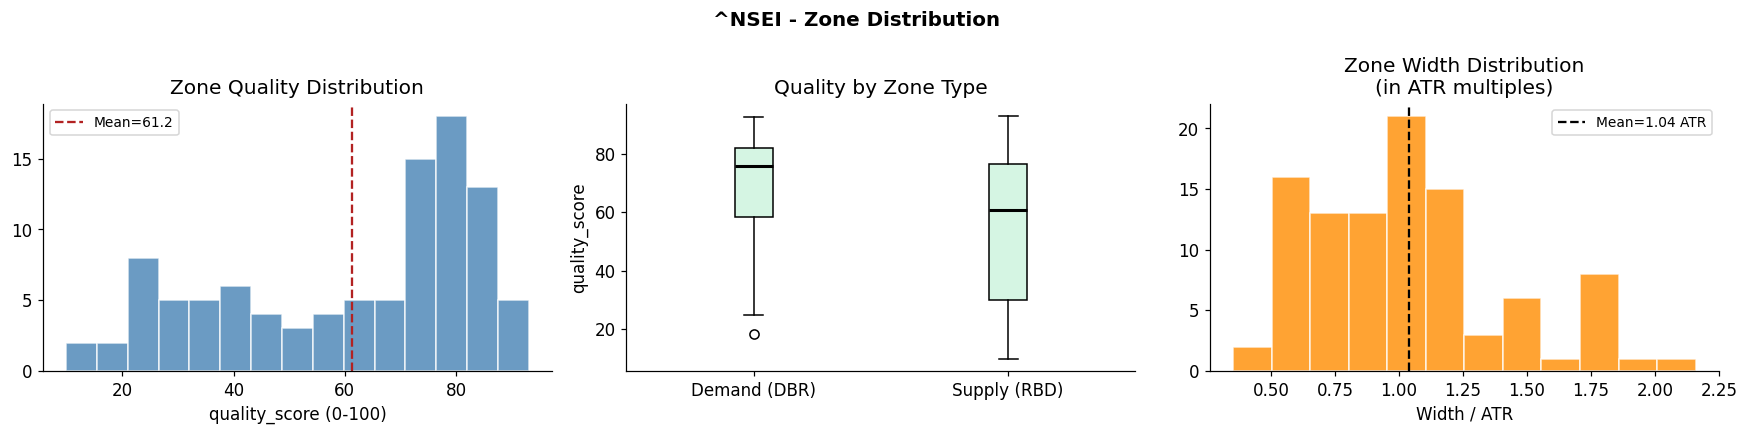

In [34]:
# -- 4b. Quality score distribution (the rebuilt, correctly-ranked score) --
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.hist(zones['quality_score'], bins=15, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(zones['quality_score'].mean(), color='firebrick', linestyle='--',
           label=f'Mean={zones["quality_score"].mean():.1f}')
ax.set_title('Zone Quality Distribution')
ax.set_xlabel('quality_score (0-100)')
ax.legend(fontsize=9)

ax2 = axes[1]
demand_s = zones[zones['type'] == 'demand']['quality_score']
supply_s = zones[zones['type'] == 'supply']['quality_score']
ax2.boxplot([demand_s, supply_s], labels=['Demand (DBR)', 'Supply (RBD)'],
            patch_artist=True, boxprops=dict(facecolor='#d5f5e3'),
            medianprops=dict(color='black', linewidth=2))
ax2.set_title('Quality by Zone Type')
ax2.set_ylabel('quality_score')

ax3 = axes[2]
ax3.hist(zones['width_atr'], bins=12, color='darkorange', alpha=0.8, edgecolor='white')
ax3.axvline(zones['width_atr'].mean(), color='black', linestyle='--',
            label=f'Mean={zones["width_atr"].mean():.2f} ATR')
ax3.set_title('Zone Width Distribution\n(in ATR multiples)')
ax3.set_xlabel('Width / ATR')
ax3.legend(fontsize=9)

plt.suptitle(f'{SYMBOL} - Zone Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

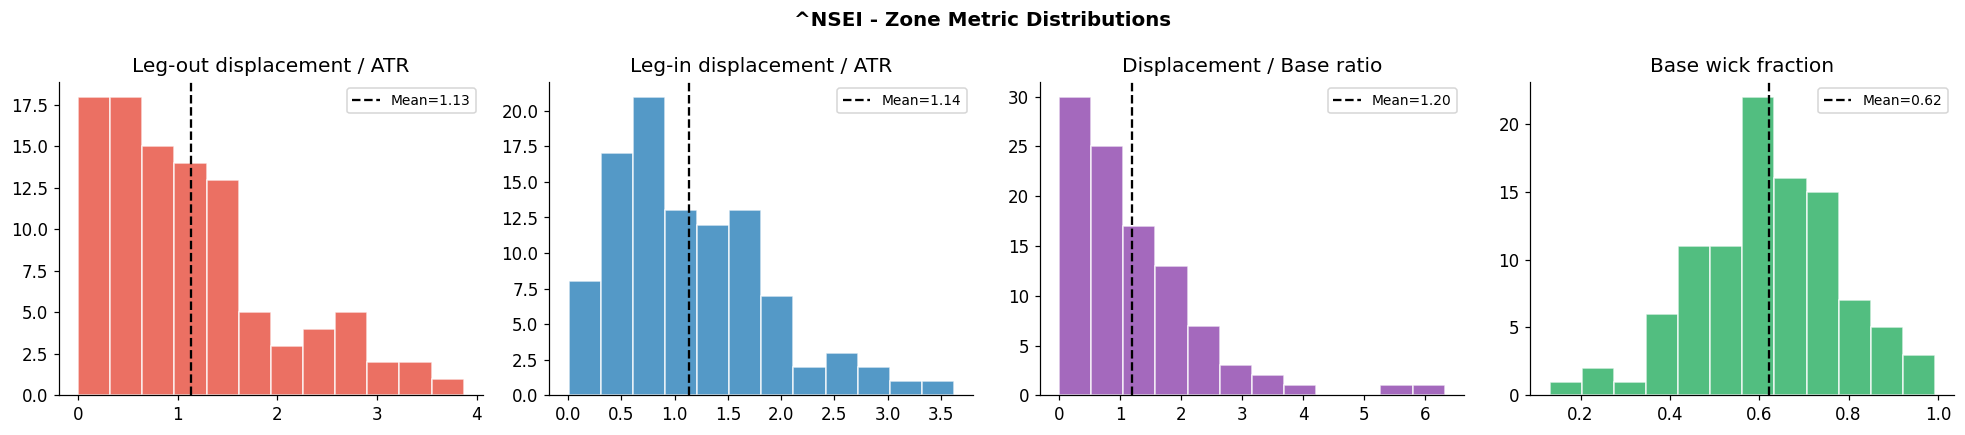

Zone metric statistics:


,count,mean,std,min,25%,50%,75%,max
leg_out_disp_atr,100.0000,1.1283,0.9144,0.0000,0.4033,0.9255,1.5360,3.8691
leg_out_candles,100.0000,3.0300,1.0096,1.0000,2.0000,3.0000,4.0000,4.0000
leg_in_disp_atr,100.0000,1.1379,0.7246,0.0034,0.6114,1.0280,1.5910,3.6260
disp_base_ratio,100.0000,1.2038,1.1315,0.0000,0.4274,0.9284,1.7903,6.3220
base_wick_frac,100.0000,0.6224,0.1594,0.1306,0.5183,0.6238,0.7290,0.9937
width_atr,100.0000,1.0409,0.3726,0.3509,0.7747,0.9866,1.2130,2.1598
quality_score,100.0000,61.2496,22.9974,9.8900,40.6900,71.2700,80.1575,93.0700


In [35]:
# -- 4c. Zone metric distributions (inputs to the new quality model) --
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics = [
    ('leg_out_disp_atr', 'Leg-out displacement / ATR', '#e74c3c'),
    ('leg_in_disp_atr',  'Leg-in displacement / ATR',  '#2980b9'),
    ('disp_base_ratio',  'Displacement / Base ratio',  '#8e44ad'),
    ('base_wick_frac',   'Base wick fraction',         '#27ae60'),
]
for ax, (col, label, color) in zip(axes, metrics):
    d = zones[col].dropna() if col in zones.columns else pd.Series(dtype=float)
    if len(d):
        ax.hist(d, bins=12, color=color, alpha=0.8, edgecolor='white')
        ax.axvline(d.mean(), color='black', linestyle='--', label=f'Mean={d.mean():.2f}')
    ax.set_title(label)
    ax.legend(fontsize=9)
plt.suptitle(f'{SYMBOL} - Zone Metric Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Zone metric statistics:')
comp_cols = [c for c in ['leg_out_disp_atr', 'leg_out_candles', 'leg_in_disp_atr',
             'disp_base_ratio', 'base_wick_frac', 'width_atr', 'quality_score']
             if c in zones.columns]
zones[comp_cols].describe().T

---
## 5 · Demand vs. Supply Zone Comparison

Demand and supply zones can behave differently.  
Markets tend to fall faster than they rise ("elevator down, escalator up"),  
which means supply zones (where price drops) may have stronger departure moves  
than demand zones (where price rallies) on average.

In [36]:
demand_zones = zones[zones['type'] == 'demand']
supply_zones = zones[zones['type'] == 'supply']

compare_cols = [
    'departure_body_atr', 'departure_close_ratio',
    'leg_in_disp_atr', 'width_atr', 'base_length', 'quality_score', 'test_count'
]

comparison = pd.DataFrame({
    'Demand (DBR)': demand_zones[compare_cols].mean(),
    'Supply (RBD)': supply_zones[compare_cols].mean(),
})
comparison['Difference'] = comparison['Supply (RBD)'] - comparison['Demand (DBR)']

print('Demand vs. Supply zone averages:')
print(comparison.to_string())
print()
print('Status breakdown by type:')
print(pd.crosstab(zones['type'], zones['status']))

Demand vs. Supply zone averages:
                       Demand (DBR)  Supply (RBD)  Difference
departure_body_atr           0.9728        1.2814      0.3087
departure_close_ratio        0.9086        0.8955     -0.0131
leg_in_disp_atr              1.1435        1.1329     -0.0106
width_atr                    1.0762        1.0095     -0.0666
base_length                  2.0426        2.0755      0.0329
quality_score               69.7009       53.7551    -15.9458
test_count                   1.4255        1.8679      0.4424

Status breakdown by type:
status  active  broken  tested
type                          
demand       2      40       5
supply       0      53       0


---
## 6 · Active and Tested Zones — Current Trading Relevance

Only **active** and **tested** zones are relevant for live trading decisions.  
This section shows where they sit relative to the current price  
and ranks them by how close they are.

In [37]:
current_price = proc['Close'].iloc[-1]
current_date  = proc.index[-1].date()
current_atr   = proc['ATR'].iloc[-1]

# Filter to live zones
live = zones[zones['status'].isin(['active', 'tested'])].copy()
live['dist_to_mid_pct'] = ((live['midpoint'] - current_price) / current_price * 100).round(2)
live['dist_to_mid_atr'] = ((live['midpoint'] - current_price) / current_atr).round(2)
live['above_price']     = live['midpoint'] > current_price

print(f'Current price : {current_price:.2f}  ({current_date})')
print(f'Current ATR   : {current_atr:.2f}')
print()
print(f'Live zones (active + tested): {len(live)}')
print()

if len(live):
    show = live[[
        'type', 'top', 'bottom', 'midpoint',
        'dist_to_mid_pct', 'dist_to_mid_atr',
        'quality_score', 'status', 'test_count', 'formation_date'
    ]].sort_values('dist_to_mid_atr', key=abs)
    print(show.to_string())
else:
    print('No active or tested zones found.')
    print('Consider relaxing zone_config.yaml parameters to detect more zones.')

Current price : 23983.40  (2026-07-01)
Current ATR   : 252.88

Live zones (active + tested): 7

           type        top     bottom   midpoint  dist_to_mid_pct  dist_to_mid_atr  quality_score  status  test_count formation_date
zone_id                                                                                                                             
Z0102    demand 22261.5508 21964.5996 22113.0752          -7.8000          -7.4000        71.5400  tested           3     2025-03-05
Z0091    demand 21766.8008 21543.3496 21655.0752          -9.7100          -9.2100        86.7300  tested           3     2024-02-14
Z0085    demand 18419.7500 18202.4004 18311.0752         -23.6500         -22.4300        92.6200  active           0     2023-05-26
Z0084    demand 17931.5996 17711.1992 17821.3994         -25.6900         -24.3700        56.9300  active           0     2023-04-28
Z0069    demand 10827.4502 10577.7500 10702.6001         -55.3700         -52.5200        76.9300  tested 

In [38]:
if len(live):
    fig_live = plot_zones_on_candles(
        proc, live,
        title=f'<b>{SYMBOL}</b>  —  Active & Tested Zones  |  Last 300 sessions  ({current_date})',
        n_candles=300,
    )
    fig_live.show()


---
## 7 · Zone Lifecycle Analysis

Understanding the lifecycle of a zone (how long it stays active, how many tests it survives  
before being invalidated or consumed) is critical for labelling future ML training data.

Key questions:
- How long do zones typically remain active before invalidation?
- Are zones that survive more tests stronger (higher strength score) on average?
- What fraction of zones are eventually invalidated vs consumed?

In [39]:
# Days from formation to invalidation
invalidated = zones[zones['status'] == 'invalid'].copy()
if len(invalidated):
    invalidated['days_to_invalid'] = (
        invalidated['invalidation_date'] - invalidated['formation_date']
    ).dt.days

    print(f'Invalidated zones: {len(invalidated)}')
    print(f'Days from formation to invalidation:')
    print(f'  Mean   : {invalidated["days_to_invalid"].mean():.0f} days')
    print(f'  Median : {invalidated["days_to_invalid"].median():.0f} days')
    print(f'  Min    : {invalidated["days_to_invalid"].min():.0f} days')
    print(f'  Max    : {invalidated["days_to_invalid"].max():.0f} days')
    print()
    print('Invalidated zones detail:')
    print(invalidated[['type', 'formation_date', 'invalidation_date',
                        'days_to_invalid', 'test_count', 'quality_score']].to_string())
else:
    print('No invalidated zones in dataset.')

No invalidated zones in dataset.


Test count distribution across all zones:
test_count
0     8
1    54
2    20
3     9
4     5
5     2
6     1
9     1



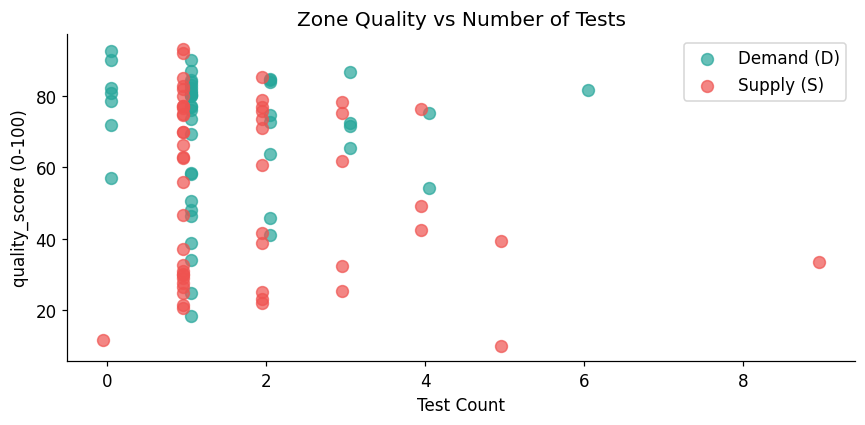

In [40]:
# Test count distribution
print('Test count distribution across all zones:')
print(zones['test_count'].value_counts().sort_index().to_string())
print()

# Quality vs test count
if zones['test_count'].max() > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    for ztype, color in [('demand', '#26a69a'), ('supply', '#ef5350')]:
        sub = zones[zones['type'] == ztype]
        ax.scatter(
            sub['test_count'] + (0.05 if ztype == 'demand' else -0.05),  # jitter
            sub['quality_score'],
            color=color, alpha=0.7, s=60,
            label=f'{ztype.capitalize()} ({ztype[0].upper()})',
        )
    ax.set_xlabel('Test Count')
    ax.set_ylabel('quality_score (0-100)')
    ax.set_title('Zone Quality vs Number of Tests')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 8 · Parameter Sensitivity Analysis

How sensitive is the zone count to each key parameter?  
This is essential before relying on any specific parameter set.

A good detector should:
- Produce roughly similar zone counts across a reasonable range of parameter values
- Not collapse to 0 or explode to hundreds if one parameter changes by 20%

If zone count is hypersensitive to a parameter, that parameter needs careful research  
before it can be trusted.

In [41]:
import copy
sys.path.insert(0, str(PROJECT_ROOT))
from src.zones.zone_detector import detect

def count_zones(proc, zcfg_override: dict) -> int:
    """Run detector with a modified config and return zone count."""
    cfg = copy.deepcopy(ZCFG)
    cfg.update(zcfg_override)
    result = detect(proc, cfg)
    return len(result) if not result.empty else 0


print('Parameter sensitivity — zone counts as each parameter varies:\n')

# departure_strength
dep_vals  = [0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5]
dep_counts = [count_zones(proc, {'departure_strength': v}) for v in dep_vals]
print(f'{"departure_strength":30s} : ' +
      '  '.join(f'{v}→{c}' for v, c in zip(dep_vals, dep_counts)))

# arrival_min_move
arr_vals   = [0.5, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]
arr_counts = [count_zones(proc, {'arrival_min_move': v}) for v in arr_vals]
print(f'{"arrival_min_move":30s} : ' +
      '  '.join(f'{v}→{c}' for v, c in zip(arr_vals, arr_counts)))

# base_range_multiplier
br_vals   = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
br_counts = [count_zones(proc, {'base_range_multiplier': v}) for v in br_vals]
print(f'{"base_range_multiplier":30s} : ' +
      '  '.join(f'{v}→{c}' for v, c in zip(br_vals, br_counts)))

# max_base_length
bl_vals   = [1, 2, 3, 4, 5, 6, 8]
bl_counts = [count_zones(proc, {'max_base_length': v}) for v in bl_vals]
print(f'{"max_base_length":30s} : ' +
      '  '.join(f'{v}→{c}' for v, c in zip(bl_vals, bl_counts)))

Parameter sensitivity — zone counts as each parameter varies:

departure_strength             : 0.6→115  0.8→90  1.0→61  1.2→41  1.5→18  2.0→4  2.5→0
arrival_min_move               : 0.5→100  0.8→100  1.0→100  1.5→100  2.0→100  2.5→100  3.0→100
base_range_multiplier          : 0.5→16  0.75→64  1.0→93  1.25→97  1.5→100  2.0→100
max_base_length                : 1→110  2→95  3→100  4→95  5→100  6→100  8→100


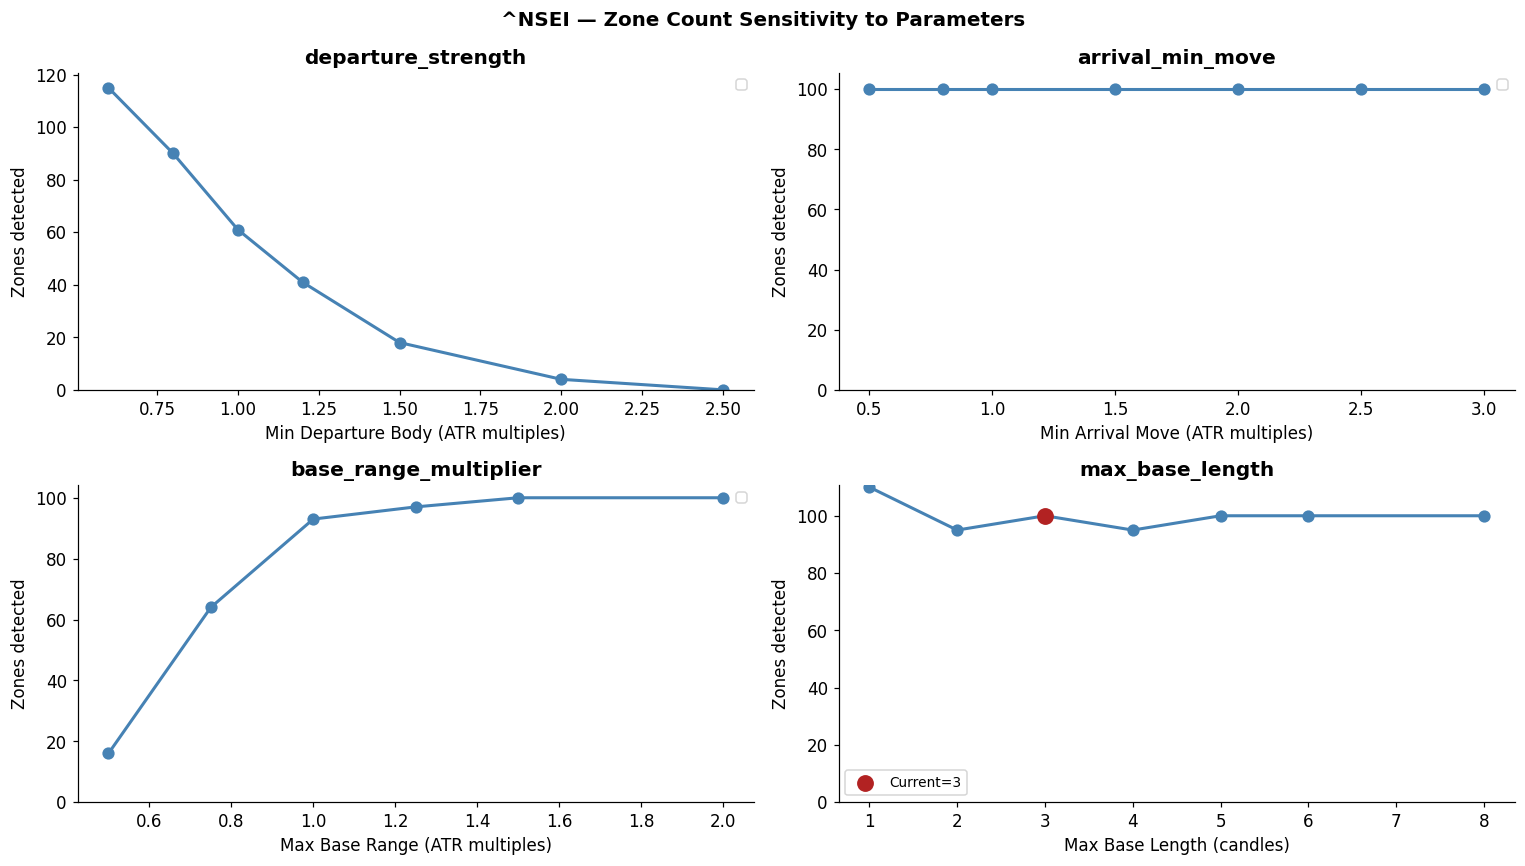

In [42]:
# Visualise sensitivity curves
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sensitivity_data = [
    (axes[0,0], dep_vals,  dep_counts,  'departure_strength',    'Min Departure Body (ATR multiples)'),
    (axes[0,1], arr_vals,  arr_counts,  'arrival_min_move',      'Min Arrival Move (ATR multiples)'),
    (axes[1,0], br_vals,   br_counts,   'base_range_multiplier', 'Max Base Range (ATR multiples)'),
    (axes[1,1], bl_vals,   bl_counts,   'max_base_length',       'Max Base Length (candles)'),
]

for ax, x_vals, y_counts, param_name, xlabel in sensitivity_data:
    ax.plot(x_vals, y_counts, 'o-', color='steelblue', linewidth=2, markersize=7)
    # Mark the current config value
    current_val = ZCFG.get(param_name)
    if current_val in x_vals:
        idx = x_vals.index(current_val)
        ax.scatter([current_val], [y_counts[idx]], color='firebrick', s=100, zorder=5,
                   label=f'Current={current_val}')
    ax.set_title(param_name, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Zones detected')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

plt.suptitle(f'{SYMBOL} — Zone Count Sensitivity to Parameters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**How to read the sensitivity curves:**
- A steep drop-off as a parameter tightens means that parameter is highly selective at its current setting.
- A flat region around the current value means the detector is robust to small changes in that parameter.
- If any parameter shows a cliff edge (many zones → 0 zones with a small change), it needs to be treated carefully and validated further before use in ML labels.

---
## 9 · Zone Strength Score Decomposition

The strength score has four components. This section shows how much each component  
contributes to the final score and whether any component is driving most of the variance.

In [43]:
# Quality drivers — how each stored metric relates to the NEW quality_score.
# (The old manual per-component recompute was removed; quality_score is computed
#  in zone_detector._quality_score from these inputs — see config quality_weights.)
drivers = [c for c in ['base_length', 'base_wick_frac', 'leg_out_disp_atr',
                       'leg_out_velocity', 'leg_in_disp_atr', 'disp_base_ratio',
                       'is_v_shape', 'weekly_confluence_score', 'trend_score']
           if c in zones.columns]
tmp = zones[drivers + ['quality_score']].apply(pd.to_numeric, errors='coerce')
corr = tmp.corr()['quality_score'].drop('quality_score').sort_values(ascending=False)
print('Correlation of each metric with quality_score:')
print(corr.round(3).to_string())

print('\nConfigured quality weights:')
for k, v in ZCFG.get('quality_weights', {}).items():
    print(f'  {k:15s}: {v}')

print('\nStrength (legacy) vs quality_score — they should NOT agree closely,')
print('since the legacy score was anti-predictive:')
print(f"  corr(strength, quality_score) = {zones[['strength','quality_score']].corr().iloc[0,1]:.3f}")

Correlation of each metric with quality_score:
trend_score                0.3720
base_wick_frac             0.2740
base_length                0.1820
leg_in_disp_atr           -0.0120
weekly_confluence_score   -0.0940
leg_out_velocity          -0.5790
leg_out_disp_atr          -0.6630
disp_base_ratio           -0.6670

Configured quality weights:
  leg_out        : 0.34
  base_structure : 0.22
  disp_base      : 0.12
  trend          : 0.12
  leg_in         : 0.05
  volume         : 0.1

Strength (legacy) vs quality_score — they should NOT agree closely,
since the legacy score was anti-predictive:
  corr(strength, quality_score) = -0.306


---
## 10 · Current Parameters Reference

A printout of the exact parameters used for this detection run.  
Record this whenever you save or share zone results — parameters should always travel with outputs.

In [44]:
print('=' * 55)
print('  Active zone_config.yaml parameters')
print('=' * 55)
skip_keys = {'scoring'}  # print scoring separately
for k, v in ZCFG.items():
    if k not in skip_keys:
        print(f'  {k:35s}: {v}')
print()
print('  Scoring weights:')
for k, v in ZCFG['scoring'].items():
    print(f'    {k:33s}: {v}')
print('=' * 55)
print()
print(f'  Symbol          : {SYMBOL}')
print(f'  Candles         : {len(proc):,}')
print(f'  Zones detected  : {len(zones)}')
print(f'  Detection date  : {pd.Timestamp.now().date()}')
print('=' * 55)

  Active zone_config.yaml parameters
  base_range_multiplier              : 1.6
  base_cluster_multiplier            : 2.5
  base_body_multiplier               : 0.7
  min_base_length                    : 1
  max_base_length                    : 3
  departure_strength                 : 0.7
  departure_close_ratio              : 0.8
  departure_leg_max                  : 4
  leg_pullback_atr                   : 0.7
  departure_leg_disp                 : 1.0
  leg_in                             : {'enabled': False, 'lookback': 3, 'min_move_atr': 0.0}
  arrival_mode                       : any
  arrival_require_origin             : False
  require_base_containment           : True
  containment_price                  : body
  invalidation_mode                  : close
  quality_weights                    : {'leg_out': 0.34, 'base_structure': 0.22, 'disp_base': 0.12, 'trend': 0.12, 'leg_in': 0.05, 'volume': 0.1}
  merge                              : {'enabled': True, 'overlap_tolerance': 

---
## 11 · Summary & Next Steps

### What was validated
- Zone detection algorithm produces structurally correct RBD/DBR patterns (verified visually in Section 3)
- All zones respect the ATR-normalised thresholds from `zone_config.yaml`
- Zone strength scores decompose cleanly into four interpretable components
- Sensitivity curves show where the detector is and is not robust to parameter changes

### Observations to carry forward
- **Zone count per year** tells you how selective the detector is — compare this to how many high-quality setups you would expect to see manually
- **Width in ATR multiples** — zones narrower than 0.3 ATR may be too tight to be reliable; zones wider than 1.5 ATR may be too wide to generate clean entries
- **Invalidation speed** — if most zones are invalidated within a few days, the `invalidation_mode` or `arrival_min_move` may be too loose
- **Sensitivity to `departure_strength`** — if zone count halves when this moves from 1.2→1.5, the detector is finding a meaningful structural edge; if it is flat, departure strength is not discriminating

### Immediate next step

The zone output at `data/zones/<SYMBOL>_zones.csv` is now ready to be used as the basis for:

| Next task | What it needs from zones |
|-----------|-------------------------|
| Candlestick pattern detection | Active zone boundaries to check if a pattern is forming at a zone |
| Feature engineering | Zone type, strength, width, distance from price, test count |
| Label generation | Was price at a zone when the reversal / breakout occurred? |
| Backtesting | Entry at zone, stop below/above zone, target at next zone |

for each candle i in the dataset:

    1. Determine if candle i is a base candle
       → range(i) < base_range_atr_multiplier × ATR(i)
       → body(i) < base_body_atr_multiplier × ATR(i)

    2. If yes, extend forward to find all consecutive base candles
       → base = [i, i+1, ..., i+k]  where k ≤ max_base_length

    3. Once base ends at candle i+k+1, examine the departure candle:
       → departure = candle at index i+k+1
       → is it a strong bullish candle? → candidate DBR
       → is it a strong bearish candle? → candidate RBD

    4. Examine the arrival: candles before index i
       → compute net price direction over last N candles
       → for DBR: arrival must be a downward leg
       → for RBD: arrival must be an upward leg

    5. If both arrival and departure pass:
       → compute zone top = max(high of base candles)
       → compute zone bottom = min(low of base candles)
       → record zone: {type, top, bottom, formation_date, strength_score}

    6. Track zone status over time:
       → if a later candle closes below zone bottom → demand zone invalidated
       → if a later candle closes above zone top → supply zone invalidated
       → each time price enters the zone without invalidating → test count += 1

---
## 7 — Weekly-Timeframe Confluence

Higher-timeframe context for the daily zones. We detect supply/demand zones on the **weekly** data (fetched directly from Yahoo Finance as `1wk` bars by `data_pipeline.py`) and overlay them on the daily chart.

A daily zone that sits **inside a weekly zone** (`weekly_in_zone == True`) is a high-conviction multi-timeframe setup — the same imbalance shows on two timeframes. Each daily zone already carries the detector's **causal** confluence features: `weekly_trend_align`, `weekly_in_zone`, `weekly_dist_atr`, `weekly_zone_strength`, `weekly_zone_fresh`, and the combined `weekly_confluence_score`.

In [45]:
# ── Weekly data + weekly zones ────────────────────────────────
from src.zones.zone_detector import detect

WEEKLY_PROC_PATH = PROJECT_ROOT / CFG['data']['processed_dir'] / f'{SAFE}_weekly.csv'

if WEEKLY_PROC_PATH.exists():
    weekly_proc = pd.read_csv(WEEKLY_PROC_PATH, index_col='Date', parse_dates=True)
    weekly_proc.index = pd.to_datetime(weekly_proc.index).tz_localize(None)
    weekly_proc.sort_index(inplace=True)
    # Same detector, one level only (enable_weekly=False → no nested weekly pass)
    weekly_zones = detect(weekly_proc, ZCFG, enable_weekly=False)
    n_wd = int((weekly_zones['type'] == 'demand').sum())
    n_ws = int((weekly_zones['type'] == 'supply').sum())
    print(f'Weekly bars  : {len(weekly_proc):,}  |  {weekly_proc.index.min().date()} -> {weekly_proc.index.max().date()}')
    print(f'Weekly zones : {len(weekly_zones)}  ({n_wd} demand / {n_ws} supply)')
else:
    weekly_proc, weekly_zones = None, pd.DataFrame()
    print(f'No weekly processed file at {WEEKLY_PROC_PATH}.')
    print(f'Run:  python data_pipeline.py --symbol {SYMBOL}')

# Confluence summary (features already on the daily zones from the detector)
if 'weekly_in_zone' in zones.columns:
    n_in    = int(zones['weekly_in_zone'].sum())
    n_fresh = int(zones['weekly_zone_fresh'].sum()) if 'weekly_zone_fresh' in zones.columns else 0
    print(f'\nDaily zones inside a weekly zone : {n_in} / {len(zones)}  (fresh weekly: {n_fresh})')
    print(f'Avg weekly_confluence_score      : {zones["weekly_confluence_score"].mean():.3f}')
else:
    print('\nDaily zones CSV has no weekly_* columns — re-run zone detection (zone_detector.py).')

Weekly bars  : 598  |  2014-12-29 -> 2026-06-08
Weekly zones : 21  (12 demand / 9 supply)

Daily zones inside a weekly zone : 23 / 100  (fresh weekly: 16)
Avg weekly_confluence_score      : 0.377


In [46]:
# ── Daily candles + weekly bands + confluence-highlighted daily zones ──
def plot_weekly_confluence(proc, zones, weekly_zones, title='', n_candles=None):
    # Daily candlesticks, WEEKLY zones drawn as wide dashed HTF bands, and daily
    # zones drawn BOLD/bright when weekly_in_zone is True (faded otherwise).
    df = proc.tail(n_candles).copy() if n_candles else proc.copy()
    dmin, dmax = df.index.min(), df.index.max()
    fig = go.Figure()

    # Weekly zones → wide HTF bands spanning the full visible width
    if weekly_zones is not None and len(weekly_zones):
        for _, w in weekly_zones.iterrows():
            if pd.Timestamp(w['formation_date']) > dmax:
                continue
            inv = w.get('invalidation_date')
            if pd.notna(inv) and pd.Timestamp(inv) < dmin:
                continue
            is_dem = w['type'] == 'demand'
            fig.add_shape(type='rect', xref='x domain', yref='y', x0=0, x1=1,
                          y0=float(w['bottom']), y1=float(w['top']),
                          fillcolor='rgba(38,166,154,0.09)' if is_dem else 'rgba(239,83,80,0.09)',
                          line=dict(color=DEMAND_LINE if is_dem else SUPPLY_LINE, width=1, dash='dash'),
                          layer='below')

    # Candlesticks
    fig.add_trace(go.Candlestick(x=df.index, open=df['Open'], high=df['High'],
                  low=df['Low'], close=df['Close'], name='Price',
                  increasing=dict(line=dict(color='#26a69a', width=1), fillcolor='#26a69a'),
                  decreasing=dict(line=dict(color='#ef5350', width=1), fillcolor='#ef5350'),
                  whiskerwidth=0.5))

    # Daily zones: bold if inside a weekly zone, faded otherwise
    for zid, z in zones.iterrows():
        fdate = pd.Timestamp(z['formation_date'])
        inv = z.get('invalidation_date')
        if pd.notna(inv) and pd.Timestamp(inv) < dmin:
            continue
        if fdate > dmax:
            continue
        is_dem = z['type'] == 'demand'
        in_wk  = bool(z.get('weekly_in_zone', False))
        line   = DEMAND_LINE if is_dem else SUPPLY_LINE
        if in_wk:
            fill = 'rgba(38,166,154,0.34)' if is_dem else 'rgba(239,83,80,0.34)'
        else:
            fill = 'rgba(38,166,154,0.08)' if is_dem else 'rgba(239,83,80,0.08)'
        x0, x1 = max(fdate, dmin), dmax
        fig.add_shape(type='rect', xref='x', yref='y', x0=x0, x1=x1,
                      y0=float(z['bottom']), y1=float(z['top']), fillcolor=fill,
                      line=dict(color=line, width=2 if in_wk else 0.7,
                                dash='solid' if in_wk else 'dot'), layer='below')
        conf  = float(z.get('weekly_confluence_score', float('nan')))
        wdist = float(z.get('weekly_dist_atr', float('nan')))
        star  = '  IN WEEKLY ZONE' if in_wk else ''
        hover = (f"<b>{zid}</b> {'Demand' if is_dem else 'Supply'}{star}<br>"
                 f"Top {z['top']:.2f}  Bottom {z['bottom']:.2f}<br>"
                 f"Quality {z['quality_score']:.0f}  |  Weekly confluence {conf:.3f}<br>"
                 f"Dist to weekly {wdist:.2f}xATR  |  fresh weekly: {bool(z.get('weekly_zone_fresh', False))}"
                 "<extra></extra>")
        fig.add_trace(go.Scatter(x=[x0, x1, x1, x0, x0],
                      y=[z['bottom'], z['bottom'], z['top'], z['top'], z['bottom']],
                      fill='toself', fillcolor='rgba(0,0,0,0)', line=dict(color='rgba(0,0,0,0)'),
                      showlegend=False, hovertemplate=hover, name=str(zid)))

    fig.update_layout(
        title=dict(text=title or f'<b>{SYMBOL}</b> - daily zones with weekly confluence',
                   font=dict(size=14, color='#d1d4dc'), x=0.0, y=0.98),
        template=CHART_THEME, paper_bgcolor=PAPER_BG, plot_bgcolor=PLOT_BG,
        height=720, margin=dict(l=65, r=25, t=50, b=40),
        xaxis_rangeslider_visible=False, hovermode='closest',
        hoverlabel=dict(bgcolor='#1e222d', font_size=11), showlegend=False)
    all_days = pd.date_range(df.index.min(), df.index.max(), freq='D')
    trading  = set(df.index.normalize())
    holidays = [d.strftime('%Y-%m-%d') for d in all_days if d not in trading and d.weekday() < 5]
    fig.update_xaxes(showgrid=True, gridcolor=GRID_COLOR,
                     rangebreaks=[dict(bounds=['sat', 'mon']), dict(values=holidays)])
    fig.update_yaxes(title_text='Price (INR)', gridcolor=GRID_COLOR, tickformat=',.0f', side='right')
    return fig


# Last ~18 months for clarity (set n_candles=None for full history)
fig_conf = plot_weekly_confluence(
    proc, zones, weekly_zones,
    title=f'<b>{SYMBOL}</b> - Daily DBR/RBD zones + weekly confluence  (bold = inside a weekly zone)',
    n_candles=360,
)
fig_conf.show()

In [47]:
# ── Weekly-timeframe chart (weekly candles + weekly zones) ──────
# Reuses the same broker-style plotter, applied to the weekly data/zones.
if weekly_proc is not None and not weekly_zones.empty:
    fig_weekly = plot_zones_on_candles(
        weekly_proc, weekly_zones,
        title=f'<b>{SYMBOL}</b> - WEEKLY timeframe supply/demand zones',
    )
    fig_weekly.show()
else:
    print('No weekly data/zones to plot - run data_pipeline.py to fetch 1wk bars.')

In [48]:
# ── The multi-timeframe setups: daily zones inside a weekly zone ──
if 'weekly_in_zone' in zones.columns:
    cols = [c for c in ['type', 'top', 'bottom', 'quality_score', 'weekly_dist_atr',
                        'weekly_zone_strength', 'weekly_zone_fresh', 'weekly_trend_align',
                        'weekly_confluence_score', 'status', 'formation_date']
            if c in zones.columns]
    confluent = (zones[zones['weekly_in_zone'] == True]
                 .sort_values('weekly_confluence_score', ascending=False))
    print(f'{len(confluent)} daily zones sit inside a weekly zone (highest confluence first):')
    out = confluent[cols]
else:
    out = pd.DataFrame()
    print('No weekly confluence columns present - re-run zone detection.')
out

23 daily zones sit inside a weekly zone (highest confluence first):


,type,top,bottom,quality_score,weekly_dist_atr,weekly_zone_strength,weekly_zone_fresh,weekly_trend_align,weekly_confluence_score,status,formation_date
zone_id,,,,,,,,,,,
Z0086,demand,19636.4492,19432.8496,54.2000,0.0000,0.7092,True,2.1904,0.9418,broken,2023-09-07
Z0007,supply,8467.1504,8405.4004,41.5300,0.0000,0.6639,True,1.3464,0.9083,broken,2015-06-02
Z0008,demand,8250.7998,8048.9502,74.5900,0.0000,0.6359,True,-0.0011,0.8521,broken,2015-06-22
Z0098,supply,25907.5996,25739.1992,20.6200,0.0000,0.6406,True,-0.8912,0.8197,broken,2024-10-03
Z0097,supply,26277.3496,26151.4004,9.8900,0.0000,0.6406,True,-0.8912,0.8197,broken,2024-09-30
Z0112,supply,23833.1504,23556.3008,80.1000,0.0000,0.5887,False,3.0066,0.8177,broken,2026-03-13
Z0013,supply,8322.2002,8225.0498,39.3700,0.0000,0.6639,False,1.4462,0.8120,broken,2015-08-24
Z0049,demand,10633.1504,10550.9004,84.4600,0.0000,0.7428,False,1.0169,0.8117,broken,2018-06-06
Z0069,demand,10827.4502,10577.7500,76.9300,0.0657,0.7428,False,1.1603,0.8089,tested,2020-07-17


---
## 8 — Quality, Structure & Entry/Stop (v3)

The rebuilt **`quality_score` (0-100)** is the primary ranking/filtering field — it favours longer/wickier bases and *moderate* leg-out displacement (the legacy `strength` was anti-predictive). Each zone now also carries true per-leg metrics, a **distal/proximal** entry-stop pair, and a **merged_count** (overlapping duplicates were consolidated).

In [49]:
# Quality tiers + the multi-timeframe setups (entry = proximal, stop = distal)
tiers = [('A (>=70)', 70, 101), ('B (55-70)', 55, 70), ('C (40-55)', 40, 55), ('D (<40)', 0, 40)]
print('Quality tiers:')
for name, lo, hi in tiers:
    s = zones[(zones['quality_score'] >= lo) & (zones['quality_score'] < hi)]
    wk = int(s['weekly_in_zone'].sum()) if 'weekly_in_zone' in s else 0
    print(f'  Tier {name:10s}: {len(s):3d} zones   (weekly-confluent {wk})')

cols = [c for c in ['type', 'structure', 'proximal', 'distal', 'quality_score',
        'leg_out_disp_atr', 'base_length', 'weekly_in_zone',
        'status', 'formation_date'] if c in zones.columns]
print('\nTop 12 zones by quality_score (entry=proximal, stop=distal):')
zones.sort_values('quality_score', ascending=False)[cols].head(12)

Quality tiers:
  Tier A (>=70)  :  52 zones   (weekly-confluent 12)
  Tier B (55-70) :  13 zones   (weekly-confluent 1)
  Tier C (40-55) :  10 zones   (weekly-confluent 3)
  Tier D (<40)   :  25 zones   (weekly-confluent 7)

Top 12 zones by quality_score (entry=proximal, stop=distal):


,type,structure,proximal,distal,quality_score,leg_out_disp_atr,base_length,weekly_in_zone,status,formation_date
zone_id,,,,,,,,,,
Z0021,supply,RBD,7170.5498,7252.3999,93.0700,1.0719,3,False,broken,2016-02-23
Z0085,demand,RBR,18362.9004,18202.4004,92.6200,0.8763,3,False,active,2023-05-26
Z0053,supply,RBD,10512.5000,10604.9004,91.9700,1.6541,2,False,broken,2018-10-17
Z0050,demand,RBR,11620.7002,11532.0000,90.2000,0.5702,3,False,broken,2018-08-27
Z0062,demand,RBR,11464.9502,11290.0498,90.0000,0.4408,3,False,broken,2019-10-17
Z0038,demand,DBR,9337.3496,9297.9502,87.0800,0.5679,2,False,broken,2017-05-10
Z0091,demand,DBR,21743.2500,21543.3496,86.7300,1.1039,1,False,tested,2024-02-14
Z0079,supply,DBD,15674.2500,15886.1504,85.4400,0.2469,3,False,broken,2022-06-16
Z0113,supply,RBD,23880.3496,24089.8008,84.9100,0.5428,3,False,broken,2026-05-29


In [50]:
# High-quality zones on the chart (quality_score >= 60) — hover shows Quality.
hq = zones[zones['quality_score'] >= 60]
print(f'{len(hq)} high-quality zones (quality_score >= 60) of {len(zones)} total.')
fig_hq = plot_zones_on_candles(
    proc, hq,
    title=f'<b>{SYMBOL}</b>  -  High-quality DBR/RBD zones (quality_score >= 60)',
)
fig_hq.show()

61 high-quality zones (quality_score >= 60) of 100 total.
